# Attention score tensors: full vs. chunked sliding window

This notebook builds the attention score tensors of both attention paths step by step,
on a tiny example, so every tensor can be printed and looked at:

1. **Full attention**: one $(L \times L)$ score matrix, masked to causal or sliding window
2. **Chunked sliding-window attention**: $n$ small $(W \times 2W)$ score matrices
3. **Same result, less memory**: both paths give identical attention weights
4. **What this means at real sizes**: number of score entries for $L$ = 128 … 2048

It uses the real functions from `src/swla/attention.py`.

**Notation:** $L$ = number of tokens, $W$ = window size = chunk size,
$n = L / W$ = number of chunks, $d$ = head dimension.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
from matplotlib.colors import ListedColormap

from swla.attention import Attention
from swla.config import Config

# Tiny example: 12 tokens, window of 4 tokens, 1 sequence, 1 head, 4 numbers per head
L, W, d = 12, 4, 4
n = L // W                      # number of chunks (here 3)

torch.manual_seed(0)
torch.set_printoptions(precision=2, sci_mode=False, linewidth=120)

# Random queries, keys, values with the shape the attention module uses: (b, h, L, d)
queries = torch.randn(1, 1, L, d)
keys = torch.randn(1, 1, L, d)
values = torch.randn(1, 1, L, d)
print(f"L = {L} tokens, W = {W}, n = {n} chunks, d = {d}")
print("queries / keys / values:", tuple(queries.shape))

L = 12 tokens, W = 4, n = 3 chunks, d = 4
queries / keys / values: (1, 1, 12, 4)


In [5]:
print(queries)
print(keys)
print(values)

tensor([[[[-1.13, -1.15, -0.25, -0.43],
          [ 0.85,  0.69, -0.32, -2.12],
          [ 0.32, -1.26,  0.35,  0.31],
          [ 0.12,  1.24,  1.12, -0.25],
          [-1.35, -1.70,  0.57,  0.79],
          [ 0.60, -1.56, -0.34,  1.85],
          [ 0.75, -0.59, -0.17,  0.18],
          [ 1.39,  1.59,  0.95, -0.84],
          [-0.61,  0.03, -0.49,  0.25],
          [ 0.44,  0.11,  0.64,  0.44],
          [-0.10,  0.79, -0.29,  0.05],
          [ 0.52,  2.30, -1.47, -1.59]]]])
tensor([[[[-0.67,  0.87,  1.06,  0.18],
          [-0.23, -0.39,  0.54, -0.40],
          [-0.45,  0.74,  1.52,  3.41],
          [-1.53, -1.23,  1.82, -0.55],
          [-0.57,  0.92,  1.11,  1.29],
          [-1.48,  2.57, -0.47,  0.34],
          [-1.63, -0.55, -0.48, -0.50],
          [-1.07,  1.11, -0.14,  0.81],
          [-0.09,  0.69, -0.84,  0.00],
          [ 0.84, -0.40,  1.04,  0.36],
          [-0.25,  2.30, -1.88, -0.05],
          [-1.04, -0.96,  0.03,  0.71]]]])
tensor([[[[ 1.65, -1.36,  0.34,  0

In [7]:
# Plot helpers: a mask is shown as visible (blue) / masked (light gray),
# attention weights as a light-to-dark blue scale (0 = light)
MASK_CMAP = ListedColormap(["#e4e2dc", "#2a78d6"])


def show_visible(ax, mask, title, xlabel="key position", ylabel="query position", xticks=None):
    visible = (~mask).int()
    ax.imshow(visible, cmap=MASK_CMAP, vmin=0, vmax=1)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(visible.shape[1]), xticks if xticks is not None else range(visible.shape[1]))
    ax.set_yticks(range(visible.shape[0]))


def show_weights(ax, weights, title, xlabel="key position", ylabel="query position", xticks=None):
    im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(weights.shape[1]), xticks if xticks is not None else range(weights.shape[1]))
    ax.set_yticks(range(weights.shape[0]))
    return im

## 1. Full attention: one $(L \times L)$ score matrix

Every query is multiplied with **every** key: `queries @ keys.T`.
Row $i$ = query of token $i$, column $j$ = key of token $j$.

In [9]:
scores_full = queries @ keys.transpose(2, 3)          # (1, 1, L, L)
print("scores shape:", tuple(scores_full.shape), "->", L * L, "entries")
print(scores_full[0, 0])

scores shape: (1, 1, 12, 12) -> 144 entries
tensor([[-0.59,  0.75, -2.22,  2.93, -1.26, -1.32,  2.80, -0.40, -0.48, -0.90, -1.88,  1.96],
        [-0.68,  0.20, -7.56, -1.56, -2.93, -0.04, -0.55, -1.79,  0.66, -0.65,  2.08, -3.06],
        [-0.90,  0.49,  0.50,  1.53, -0.56, -3.78, -0.15, -1.55, -1.19,  1.25, -3.66,  1.10],
        [ 2.13,  0.19,  1.72,  0.46,  1.99,  2.39, -1.29,  0.90, -0.10,  0.68,  0.73, -1.45],
        [ 0.17,  0.97,  2.91,  4.76,  0.86, -2.36,  2.47,  0.11, -1.51,  0.41, -4.68,  3.62],
        [-1.79, -0.45,  4.38, -0.64,  0.24, -4.09, -0.88, -0.83, -0.84,  1.44, -3.18,  2.17],
        [-1.17, -0.11, -0.41, -0.84, -0.92, -2.47, -0.91, -1.28, -0.33,  0.75, -1.22, -0.10],
        [ 1.30, -0.09, -0.88, -1.90,  0.63,  1.29, -3.17, -0.53,  0.17,  1.22,  1.57, -3.54],
        [-0.04, -0.24,  0.40, -0.13,  0.15,  1.30,  1.09,  0.96,  0.49, -0.95,  1.14,  0.77],
        [ 0.56,  0.03,  2.37,  0.11,  1.13, -0.52, -1.31, -0.08, -0.50,  1.15, -1.08, -0.23],
        [ 0.46, 

### The masks

Both masks come from `Attention._full_mask` (built with `torch.triu` / `torch.tril`).
`True` = masked out. In the plots: **blue = visible**, gray = masked.

- **Causal** (global layers): every token sees itself and all earlier tokens.
- **Sliding window** (reference for local layers): additionally, keys $W$ or more tokens
  back are masked, so every token sees exactly the last $W$ tokens.

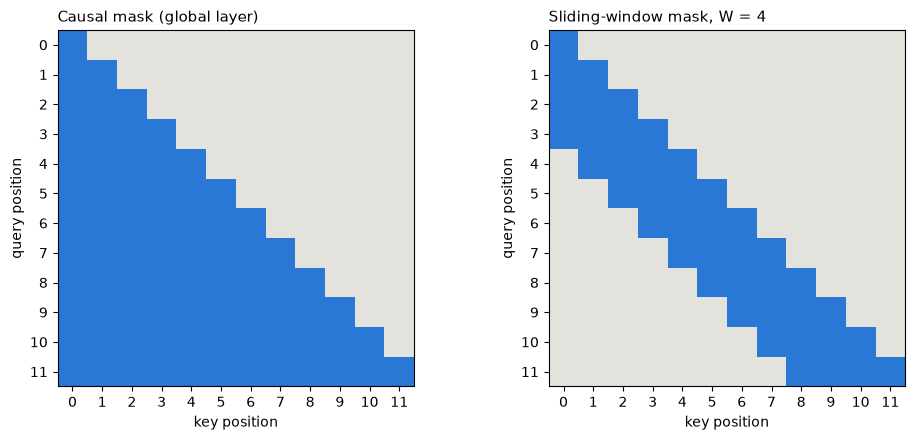

visible keys per query, causal:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
visible keys per query, sliding: [1, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4]


In [11]:
causal_mask = Attention._full_mask(L, "cpu")
sliding_mask = Attention._full_mask(L, "cpu", window_size=W)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
show_visible(axes[0], causal_mask, "Causal mask (global layer)")
show_visible(axes[1], sliding_mask, f"Sliding-window mask, W = {W}")
plt.tight_layout()
plt.show()

print("visible keys per query, causal: ", (~causal_mask).sum(dim=1).tolist())
print("visible keys per query, sliding:", (~sliding_mask).sum(dim=1).tolist())

In [ ]:
print(sliding_mask)

### Masked scores → softmax → attention weights

Masked positions get $-\infty$, so softmax gives them weight exactly 0.
Each row of the weights sums to 1.

**The problem:** with the sliding-window mask, most of the matrix is 0, but it is still
an $(L \times L)$ matrix in memory. Masking alone saves nothing.

row sums: tensor([1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00])
non-zero weights: 42 of 144 entries stored


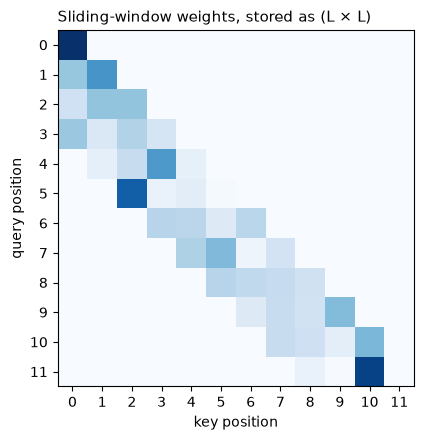

In [17]:
masked = scores_full.masked_fill(sliding_mask, -torch.inf)
weights_full = torch.softmax(masked / d**0.5, dim=-1)[0, 0]   # (L, L)

print("row sums:", weights_full.sum(dim=1))
print(f"non-zero weights: {int((weights_full > 0).sum())} of {L * L} entries stored")

fig, ax = plt.subplots(figsize=(5, 4.5))
show_weights(ax, weights_full, "Sliding-window weights, stored as (L × L)")
plt.tight_layout()
plt.show()

In [19]:
print(masked)
print(weights_full)

tensor([[[[-0.59,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [-0.68,  0.20,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [-0.90,  0.49,  0.50,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [ 2.13,  0.19,  1.72,  0.46,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [ -inf,  0.97,  2.91,  4.76,  0.86,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [ -inf,  -inf,  4.38, -0.64,  0.24, -4.09,  -inf,  -inf,  -inf,  -inf,  -inf,  -inf],
          [ -inf,  -inf,  -inf, -0.84, -0.92, -2.47, -0.91,  -inf,  -inf,  -inf,  -inf,  -inf],
          [ -inf,  -inf,  -inf,  -inf,  0.63,  1.29, -3.17, -0.53,  -inf,  -inf,  -inf,  -inf],
          [ -inf,  -inf,  -inf,  -inf,  -inf,  1.30,  1.09,  0.96,  0.49,  -inf,  -inf,  -inf],
          [ -inf,  -inf,  -inf,  -inf,  -inf,  -inf, -1.31, -0.08, -0.50,  1.15,  -inf,  -inf],
          [ -inf,  -inf,  -inf,  -inf,  

## 2. Chunked sliding-window attention: $n$ small $(W \times 2W)$ matrices

Idea: only compute the scores that can be non-zero. These are the steps of
`Attention._chunked_sliding_attention`.

### Steps 1–2: split the sequence into chunks of $W$ tokens

`.view()` only changes the shape: $(L, d) \to (n, W, d)$. No data is copied.
($L$ = 12 is a multiple of $W$ = 4, so no padding is needed here.)

In [21]:
q_chunks = queries.view(1, 1, n, W, d)
k_chunks = keys.view(1, 1, n, W, d)
v_chunks = values.view(1, 1, n, W, d)
print("chunked queries:", tuple(q_chunks.shape), "= (b, h, n, W, d)")

positions = torch.arange(L).view(n, W)
for c in range(n):
    print(f"chunk {c}: tokens {positions[c].tolist()}")

chunked queries: (1, 1, 3, 4, 4) = (b, h, n, W, d)
chunk 0: tokens [0, 1, 2, 3]
chunk 1: tokens [4, 5, 6, 7]
chunk 2: tokens [8, 9, 10, 11]


In [23]:
print(q_chunks)

tensor([[[[[-1.13, -1.15, -0.25, -0.43],
           [ 0.85,  0.69, -0.32, -2.12],
           [ 0.32, -1.26,  0.35,  0.31],
           [ 0.12,  1.24,  1.12, -0.25]],

          [[-1.35, -1.70,  0.57,  0.79],
           [ 0.60, -1.56, -0.34,  1.85],
           [ 0.75, -0.59, -0.17,  0.18],
           [ 1.39,  1.59,  0.95, -0.84]],

          [[-0.61,  0.03, -0.49,  0.25],
           [ 0.44,  0.11,  0.64,  0.44],
           [-0.10,  0.79, -0.29,  0.05],
           [ 0.52,  2.30, -1.47, -1.59]]]]])


### Step 3: keys of the previous chunk + own chunk → $2W$ keys per chunk

A query needs the last $W$ tokens. The first query of a chunk needs $W - 1$ tokens from
the **previous** chunk, so each chunk gets the keys `[previous chunk | own chunk]`.
Chunk 0 has no previous chunk: it gets a chunk of zeros (padding, shown as `-`).

In [25]:
k_prev = torch.nn.functional.pad(k_chunks, (0, 0, 0, 0, 1, 0))[:, :, :-1]
k_two = torch.cat([k_prev, k_chunks], dim=3)                 # (1, 1, n, 2W, d)
v_prev = torch.nn.functional.pad(v_chunks, (0, 0, 0, 0, 1, 0))[:, :, :-1]
v_two = torch.cat([v_prev, v_chunks], dim=3)
print("keys per chunk:", tuple(k_two.shape), "= (b, h, n, 2W, d)")

# Which token does each of the 2W key slots belong to? (-1 = zero padding)
key_positions = torch.cat([positions - W, positions], dim=1)  # (n, 2W)
for c in range(n):
    slots = ["-" if p < 0 else str(p) for p in key_positions[c].tolist()]
    print(f"chunk {c}: queries {positions[c].tolist()}  keys [{' '.join(slots[:W])} | {' '.join(slots[W:])}]")

keys per chunk: (1, 1, 3, 8, 4) = (b, h, n, 2W, d)
chunk 0: queries [0, 1, 2, 3]  keys [- - - - | 0 1 2 3]
chunk 1: queries [4, 5, 6, 7]  keys [0 1 2 3 | 4 5 6 7]
chunk 2: queries [8, 9, 10, 11]  keys [4 5 6 7 | 8 9 10 11]


In [35]:
print(q_chunks)
k_two.transpose(-2, -1)

tensor([[[[[-1.13, -1.15, -0.25, -0.43],
           [ 0.85,  0.69, -0.32, -2.12],
           [ 0.32, -1.26,  0.35,  0.31],
           [ 0.12,  1.24,  1.12, -0.25]],

          [[-1.35, -1.70,  0.57,  0.79],
           [ 0.60, -1.56, -0.34,  1.85],
           [ 0.75, -0.59, -0.17,  0.18],
           [ 1.39,  1.59,  0.95, -0.84]],

          [[-0.61,  0.03, -0.49,  0.25],
           [ 0.44,  0.11,  0.64,  0.44],
           [-0.10,  0.79, -0.29,  0.05],
           [ 0.52,  2.30, -1.47, -1.59]]]]])


tensor([[[[[ 0.00,  0.00,  0.00,  0.00, -0.67, -0.23, -0.45, -1.53],
           [ 0.00,  0.00,  0.00,  0.00,  0.87, -0.39,  0.74, -1.23],
           [ 0.00,  0.00,  0.00,  0.00,  1.06,  0.54,  1.52,  1.82],
           [ 0.00,  0.00,  0.00,  0.00,  0.18, -0.40,  3.41, -0.55]],

          [[-0.67, -0.23, -0.45, -1.53, -0.57, -1.48, -1.63, -1.07],
           [ 0.87, -0.39,  0.74, -1.23,  0.92,  2.57, -0.55,  1.11],
           [ 1.06,  0.54,  1.52,  1.82,  1.11, -0.47, -0.48, -0.14],
           [ 0.18, -0.40,  3.41, -0.55,  1.29,  0.34, -0.50,  0.81]],

          [[-0.57, -1.48, -1.63, -1.07, -0.09,  0.84, -0.25, -1.04],
           [ 0.92,  2.57, -0.55,  1.11,  0.69, -0.40,  2.30, -0.96],
           [ 1.11, -0.47, -0.48, -0.14, -0.84,  1.04, -1.88,  0.03],
           [ 1.29,  0.34, -0.50,  0.81,  0.00,  0.36, -0.05,  0.71]]]]])

### Step 4: scores per chunk → shape $(n, W, 2W)$

Each chunk multiplies its $W$ queries with its $2W$ keys.
Total entries: $n \cdot W \cdot 2W = 2 \cdot L \cdot W$ instead of $L \cdot L$.

In [37]:
scores_chunk = q_chunks @ k_two.transpose(-2, -1)            # (1, 1, n, W, 2W)
print("scores shape:", tuple(scores_chunk.shape))
print(f"entries: n * W * 2W = {n} * {W} * {2 * W} = {scores_chunk.numel()}   (full: L * L = {L * L})")
print("\nchunk 1 scores (rows = its queries, columns = its 2W keys):")
print(scores_chunk[0, 0, 1])

scores shape: (1, 1, 3, 4, 8)
entries: n * W * 2W = 3 * 4 * 8 = 96   (full: L * L = 144)

chunk 1 scores (rows = its queries, columns = its 2W keys):
tensor([[ 0.17,  0.97,  2.91,  4.76,  0.86, -2.36,  2.47,  0.11],
        [-1.79, -0.45,  4.38, -0.64,  0.24, -4.09, -0.88, -0.83],
        [-1.17, -0.11, -0.41, -0.84, -0.92, -2.47, -0.91, -1.28],
        [ 1.30, -0.09, -0.88, -1.90,  0.63,  1.29, -3.17, -0.53]])


In [39]:
print(scores_chunk)

tensor([[[[[ 0.00,  0.00,  0.00,  0.00, -0.59,  0.75, -2.22,  2.93],
           [ 0.00,  0.00,  0.00,  0.00, -0.68,  0.20, -7.56, -1.56],
           [ 0.00,  0.00,  0.00,  0.00, -0.90,  0.49,  0.50,  1.53],
           [ 0.00,  0.00,  0.00,  0.00,  2.13,  0.19,  1.72,  0.46]],

          [[ 0.17,  0.97,  2.91,  4.76,  0.86, -2.36,  2.47,  0.11],
           [-1.79, -0.45,  4.38, -0.64,  0.24, -4.09, -0.88, -0.83],
           [-1.17, -0.11, -0.41, -0.84, -0.92, -2.47, -0.91, -1.28],
           [ 1.30, -0.09, -0.88, -1.90,  0.63,  1.29, -3.17, -0.53]],

          [[ 0.15,  1.30,  1.09,  0.96,  0.49, -0.95,  1.14,  0.77],
           [ 1.13, -0.52, -1.31, -0.08, -0.50,  1.15, -1.08, -0.23],
           [ 0.53,  2.34, -0.16,  1.08,  0.80, -0.69,  2.39, -0.62],
           [-1.86,  5.30, -0.62,  0.94,  2.76, -2.58,  8.02, -3.92]]]]])


### Step 5: the chunk mask

One $(W \times 2W)$ pattern, the same for every chunk (`Attention._chunk_mask`).
Query $i$ sits at key slot $W + i$, so the visible keys form a diagonal band of width $W$.
Chunk 0 additionally masks its whole "previous" half, because that half is zero padding.

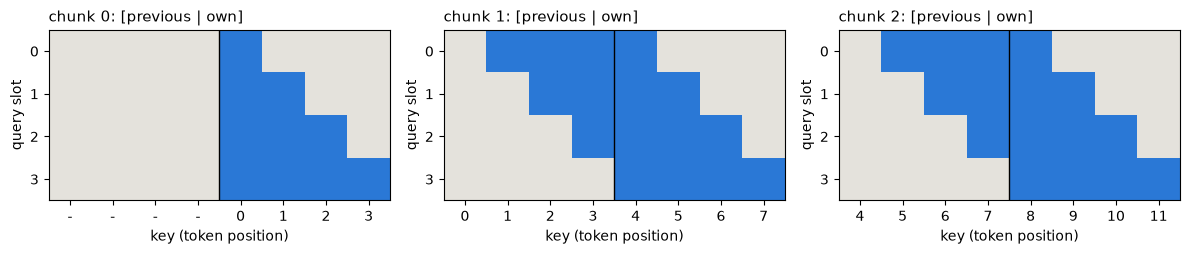

visible keys per query, every chunk: [[1, 2, 3, 4], [4, 4, 4, 4], [4, 4, 4, 4]]


In [41]:
chunk_mask = Attention._chunk_mask(n, W, "cpu")              # (n, W, 2W)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
for c in range(n):
    slots = ["-" if p < 0 else str(p) for p in key_positions[c].tolist()]
    show_visible(axes[c], chunk_mask[c], f"chunk {c}: [previous | own]",
                 xlabel="key (token position)", ylabel="query slot", xticks=slots)
    axes[c].axvline(W - 0.5, color="black", linewidth=1)    # boundary previous | own
plt.tight_layout()
plt.show()

print("visible keys per query, every chunk:", (~chunk_mask).sum(dim=2).tolist())

### Step 6: softmax → attention weights per chunk

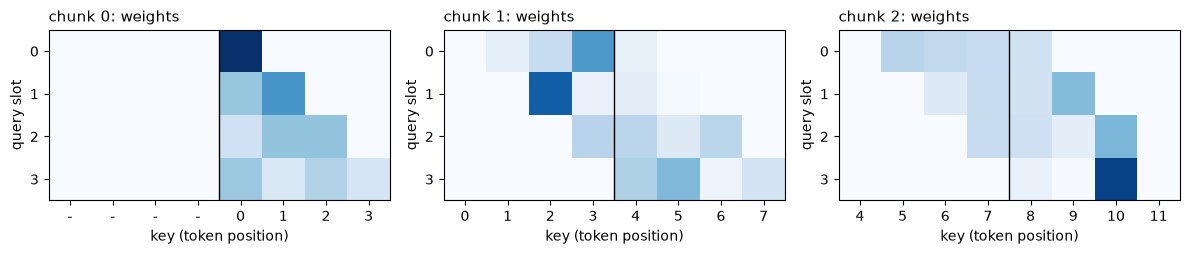

stored weights: 96 entries


In [43]:
weights_chunk = torch.softmax(scores_chunk.masked_fill(chunk_mask, -torch.inf) / d**0.5, dim=-1)[0, 0]

fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
for c in range(n):
    slots = ["-" if p < 0 else str(p) for p in key_positions[c].tolist()]
    show_weights(axes[c], weights_chunk[c], f"chunk {c}: weights",
                 xlabel="key (token position)", ylabel="query slot", xticks=slots)
    axes[c].axvline(W - 0.5, color="black", linewidth=1)
plt.tight_layout()
plt.show()
print("stored weights:", weights_chunk.numel(), "entries")

## 3. Same result, less memory

Put every chunk weight back at its (query, key) position in an $(L \times L)$ matrix
and compare it with the full sliding-window weights from part 1.

identical weights: True


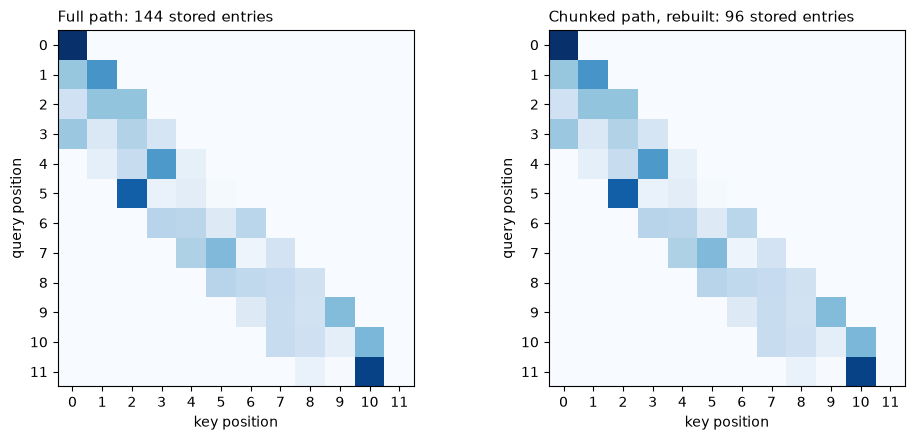

In [45]:
rebuilt = torch.zeros(L, L)
for c in range(n):
    for i in range(W):                     # query slot -> token position
        for j in range(2 * W):             # key slot   -> token position
            key_pos = key_positions[c, j].item()
            if key_pos >= 0:
                rebuilt[c * W + i, key_pos] = weights_chunk[c, i, j]

print("identical weights:", torch.allclose(rebuilt, weights_full, atol=1e-6))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
show_weights(axes[0], weights_full, f"Full path: {L * L} stored entries")
show_weights(axes[1], rebuilt, f"Chunked path, rebuilt: {weights_chunk.numel()} stored entries")
plt.tight_layout()
plt.show()

The real module gives the same context vectors on both paths (this is also what
`tests/test_attention.py` checks, including the gradients):

In [49]:
attn = Attention(Config(hidden_size=d, num_heads=1, window_size=W))
out_chunked = attn._chunked_sliding_attention(queries, keys, values)
out_full = attn._full_attention(queries, keys, values, window_size=W)
print("same context vectors:", torch.allclose(out_chunked, out_full, atol=1e-6))
print(out_chunked)

same context vectors: True
tensor([[[[ 1.65, -1.36,  0.34,  0.52],
          [-0.94, -1.56, -0.00,  0.37],
          [-0.62, -0.92,  0.11,  0.40],
          [ 0.40, -0.88,  0.33,  0.23],
          [ 0.08, -0.85,  0.52, -0.42],
          [ 0.22, -0.24,  0.31,  0.31],
          [ 0.02, -1.04,  0.64, -0.41],
          [ 0.35, -0.44, -0.18,  0.20],
          [-0.02,  0.19,  0.31,  0.33],
          [ 0.05,  0.34,  1.17, -0.08],
          [-0.13,  0.29, -0.03, -0.23],
          [-0.13,  0.08, -0.60, -1.12]]]])


## 4. What this means at real sizes

In the tiny example the chunked path even stores more entries than needed
($2W$ keys per query, half of them masked). The saving grows with $L$:
full attention stores $L^2$ entries per head, chunked attention $2 \cdot L \cdot W$,
so the factor is $L / 2W$.

Below: the experiment's window ($W$ = 32) and model (8 heads, 10 layers, every 5th layer
global), float32 = 4 bytes per entry, one score tensor per layer.

In [51]:
W_exp, heads, layers, global_every = 32, 8, 10, 5
n_global = layers // global_every
n_local = layers - n_global

print(f"{'L':>6} {'full: L*L':>12} {'chunked: 2LW':>13} {'factor':>7}"
      f" {'baseline MB':>12} {'4:1 model MB':>13} {'saving':>7}")
for L_exp in (128, 512, 1024, 2048):
    full, chunked = L_exp * L_exp, 2 * L_exp * W_exp
    baseline_mb = layers * heads * full * 4 / 1e6
    ratio_mb = (n_global * full + n_local * chunked) * heads * 4 / 1e6
    print(f"{L_exp:>6} {full:>12,} {chunked:>13,} {full / chunked:>6.0f}x"
          f" {baseline_mb:>12.1f} {ratio_mb:>13.1f} {100 * (ratio_mb / baseline_mb - 1):>6.1f}%")

     L    full: L*L  chunked: 2LW  factor  baseline MB  4:1 model MB  saving
   128       16,384         8,192      2x          5.2           3.1  -40.0%
   512      262,144        32,768      8x         83.9          25.2  -70.0%
  1024    1,048,576        65,536     16x        335.5          83.9  -75.0%
  2048    4,194,304       131,072     32x       1342.2         302.0  -77.5%


**Reading the table:**

- Per local layer the saving is the factor $L / 2W$: 2× at $L$ = 128, 32× at $L$ = 2048.
- For the whole 4:1 model the saving levels off at −80 %: the 2 global layers keep their
  full $L^2$ scores. This is the dashed "theory" line in `results/figures/relative.png`.
- The measured RAM saving is smaller (−34 % peak RAM at $L$ = 2048), because weights,
  optimizer states and the other activations are the same in both models.